In [2]:
import pandas as pd 
import numpy as np  
import matplotlib.pyplot as plt     
import seaborn as sns

In [3]:
df = pd.read_csv(r"C:\Users\rosha\OneDrive\Desktop\ml project\aqi.csv")

In [4]:
print("First 5 rows \n")
print(df.head())
print("\n"*3)
print("Describing the vars \n")
print(df.describe())
print("\n"*3)
print("Info of the dataset \n")
print(df.info())

First 5 rows 

  country  state        city                           station  \
0   India  Bihar       Arrah      New DM Office, Arrah - BSPCB   
1   India  Bihar       Arrah      New DM Office, Arrah - BSPCB   
2   India  Bihar  Aurangabad  Gurdeo Nagar, Aurangabad - BSPCB   
3   India  Bihar   Begusarai    Lohiyanagar, Begusarai - BSPCB   
4   India  Bihar   Begusarai    Lohiyanagar, Begusarai - BSPCB   

           last_update  latitude  longitude pollutant_id  pollutant_min  \
0  26-02-2026 19:00:00  25.56261  84.663264        PM2.5           48.0   
1  26-02-2026 19:00:00  25.56261  84.663264        OZONE            5.0   
2  26-02-2026 19:00:00  24.75746  84.366208          SO2            3.0   
3  26-02-2026 19:00:00  25.42742  86.138861         PM10           42.0   
4  26-02-2026 19:00:00  25.42742  86.138861          NO2           10.0   

   pollutant_max  pollutant_avg  
0          371.0           88.0  
1           13.0            8.0  
2           21.0           10.0  
3

In [5]:
print(df['country'].value_counts())

country
India    3281
Name: count, dtype: int64


In [6]:
print(df['pollutant_id'].value_counts())

pollutant_id
PM2.5    485
PM10     483
NO2      481
CO       475
SO2      466
OZONE    465
NH3      426
Name: count, dtype: int64


In [7]:
print(df.isnull().value_counts())

country  state  city   station  last_update  latitude  longitude  pollutant_id  pollutant_min  pollutant_max  pollutant_avg
False    False  False  False    False        False     False      False         False          False          False            3083
                                                                                True           True           True              198
Name: count, dtype: int64


In [8]:
null_rows = df[df.isnull().any(axis=1)]
print(f"Total rows with at least one null: {len(null_rows)}\n")

print("Null pattern in those rows:")
print(null_rows.isnull().sum())
print()

Total rows with at least one null: 198

Null pattern in those rows:
country            0
state              0
city               0
station            0
last_update        0
latitude           0
longitude          0
pollutant_id       0
pollutant_min    198
pollutant_max    198
pollutant_avg    198
dtype: int64



The value counts of the null values matches with the total number of rows with at least one null value. This shows that when the null values for one of the pollutant variables is one, it is reflected for the other two variables as well. Since that is the case, it makes more sense to drop all the null values instead of doing any commutation on them.

In [9]:
df.dropna(inplace = True)

In [10]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 3083 entries, 0 to 3280
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3083 non-null   object 
 1   state          3083 non-null   object 
 2   city           3083 non-null   object 
 3   station        3083 non-null   object 
 4   last_update    3083 non-null   object 
 5   latitude       3083 non-null   float64
 6   longitude      3083 non-null   float64
 7   pollutant_id   3083 non-null   object 
 8   pollutant_min  3083 non-null   float64
 9   pollutant_max  3083 non-null   float64
 10  pollutant_avg  3083 non-null   float64
dtypes: float64(5), object(6)
memory usage: 289.0+ KB
None


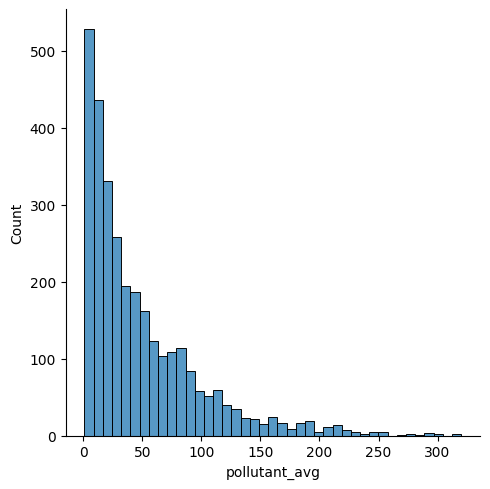

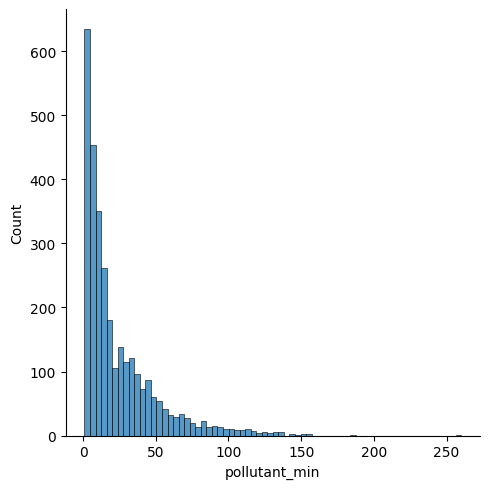

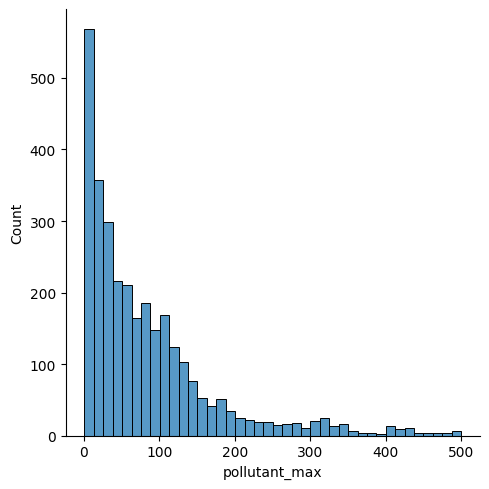

In [11]:
sns.displot(df['pollutant_avg'])
plt.show()
sns.displot(df['pollutant_min'])
plt.show()
sns.displot(df['pollutant_max'])
plt.show()

In [12]:
print(df['last_update'].value_counts())

last_update
26-02-2026 19:00:00    3083
Name: count, dtype: int64


Since the last update column only specifies one date which is honestly not relevant to the data, we can drop it. The same is true about the country column which we will drop as well.

In [13]:
df.drop(columns = ['country', 'last_update'], inplace = True)

Also since the latitude and longitude perform the same function as the state, city and the station column, we can drop those as well

In [14]:
df.drop(columns = ['state', 'city','station'], inplace = True)

In [15]:
print(df.describe())

          latitude    longitude  pollutant_min  pollutant_max  pollutant_avg
count  3083.000000  3083.000000    3083.000000    3083.000000    3083.000000
mean     23.253542    78.583871      24.014921      83.920856      48.820629
std       5.065452     4.936146      26.693621      89.389484      49.670987
min       8.514909    70.776774       1.000000       1.000000       1.000000
25%      19.235581    75.373200       6.000000      20.000000      13.000000
50%      23.697936    77.310100      14.000000      57.000000      32.000000
75%      27.308328    80.854941      34.000000     113.000000      70.500000
max      34.066206    94.636574     260.000000     500.000000     320.000000


Keeping both pollution min and pollution max can cause multicollinearality since if max is high then avg will also be high and min will likely follow along. However, while this problem can exist, dropping those features also does not make sense as it shows the spread of the pollutants present in the air. So, instead of keeping two seperate features, we will combine them into one which is called pollution_range which will just be max - min.

In [16]:
df['pollutant_range'] = df['pollutant_max'] - df['pollutant_min']

In [17]:
pivot_df = df.pivot_table(
    index=['latitude', 'longitude'], 
    columns='pollutant_id', 
    values=['pollutant_avg', 'pollutant_range']
)

Pivoting multiple aggregated values inherently creates a multi-level hierarchical column structure. we used a list comprehension to parse the column tuples and construct flat, ML-compatible feature names. Finally, we used .reset_index() to extract the spatial coordinates from the row labels, ensuring the algorithm could process them as independent continuous variables.

In [18]:
pivot_df.columns = [f"{col[1]}_{col[0].split('_')[1]}" for col in pivot_df.columns]
pivot_df = pivot_df.reset_index()

In [26]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'OZONE', 'NH3']
avg_cols = [f"{p}_avg" for p in pollutants if f"{p}_avg" in pivot_df.columns]
pivot_df['Calculated_AQI'] = pivot_df[avg_cols].max(axis=1)
print(pivot_df['Calculated_AQI'].value_counts())

Calculated_AQI
94.0     40
78.0     11
86.0      9
100.0     9
111.0     9
         ..
230.0     1
164.0     1
205.0     1
160.0     1
166.0     1
Name: count, Length: 166, dtype: int64


In [20]:
pollutants = ['PM2.5', 'PM10', 'NO2', 'CO', 'SO2', 'OZONE', 'NH3']
avg_cols = [f"{p}_avg" for p in pollutants if f"{p}_avg" in pivot_df.columns]
pivot_df['Calculated_AQI'] = pivot_df[avg_cols].max(axis=1)

In [22]:
for col in pivot_df.columns:
    if col not in ['latitude', 'longitude', 'Calculated_AQI']:
        pivot_df[col] = pivot_df[col].fillna(pivot_df[col].median())

In [23]:
print(pivot_df.info())
print(pivot_df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 487 entries, 0 to 486
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   latitude        487 non-null    float64
 1   longitude       487 non-null    float64
 2   CO_avg          487 non-null    float64
 3   NH3_avg         487 non-null    float64
 4   NO2_avg         487 non-null    float64
 5   OZONE_avg       487 non-null    float64
 6   PM10_avg        487 non-null    float64
 7   PM2.5_avg       487 non-null    float64
 8   SO2_avg         487 non-null    float64
 9   CO_range        487 non-null    float64
 10  NH3_range       487 non-null    float64
 11  NO2_range       487 non-null    float64
 12  OZONE_range     487 non-null    float64
 13  PM10_range      487 non-null    float64
 14  PM2.5_range     487 non-null    float64
 15  SO2_range       487 non-null    float64
 16  Calculated_AQI  487 non-null    float64
dtypes: float64(17)
memory usage: 64.8 K

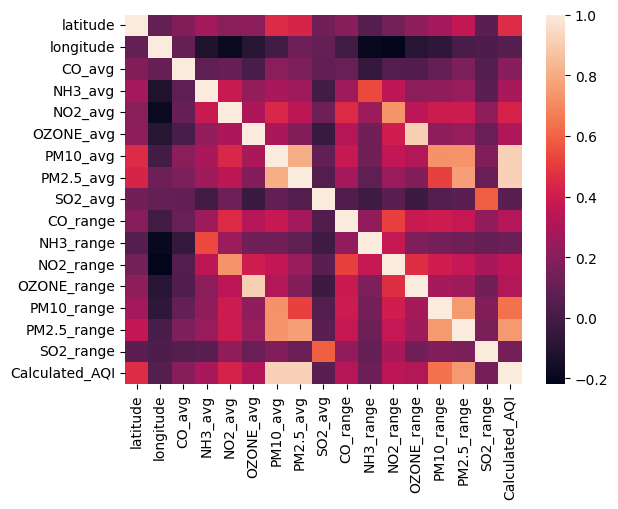

In [28]:
sns.heatmap(pivot_df.corr())
plt.show()

In [29]:
print(pivot_df.describe())

         latitude   longitude      CO_avg     NH3_avg     NO2_avg   OZONE_avg  \
count  487.000000  487.000000  487.000000  487.000000  487.000000  487.000000   
mean    23.074659   78.568490   32.525667    6.273101   33.794661   47.092402   
std      5.225656    4.921639   20.219140    4.375549   25.277369   35.884039   
min      8.514909   70.776774    2.000000    1.000000    1.000000    1.000000   
25%     19.189961   75.282818   18.000000    4.000000   16.000000   22.000000   
50%     23.555190   77.300590   28.000000    5.000000   28.000000   37.000000   
75%     27.214455   80.674273   40.000000    8.000000   42.000000   65.500000   
max     34.066206   94.636574  115.000000   37.000000  167.000000  284.000000   

         PM10_avg   PM2.5_avg     SO2_avg    CO_range   NH3_range   NO2_range  \
count  487.000000  487.000000  487.000000  487.000000  487.000000  487.000000   
mean   103.792608   92.086242   15.552361   47.406571    4.848049   39.246407   
std     46.735312   58.7706